In [1]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.


In [2]:
# =============================================================================
# Evaluation Benchmark & Ablation Protocol
# Models: SVM, RF, GBM, CNN, LSTM, CNN-LSTM, TCN
# Protocols: session-blocked (mixed k-fold) and leave-one-participant-out
# Metrics: Macro-F1, Balanced Accuracy, Accuracy
# =============================================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from Python.integrations import load_gym_dataset
from Python.windows import create_adaptive_windows
from Python.feature_engineering import engineer_robust_features
from Python.posthoc import ML4QSFlexiblePipeline
from Python.evaluation import run_full_evaluation, print_benchmark_summary, print_ablation_summary

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

In [3]:
# ── 1. LOAD & CLEAN DATA ─────────────────────────────────────────────────────
print("Loading dataset...")
raw_data = load_gym_dataset(Path("./Datasets/cropped"))

print(f"Total samples  : {len(raw_data):,}")
print(f"Participants   : {sorted(raw_data['participant'].unique())}")
print(f"Activities     : {sorted(raw_data['activity_label'].unique())}")
print(f"Sessions/person: {raw_data.groupby('participant')['session'].nunique().to_dict()}")

SENSOR_COLS = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "grav_x", "grav_y", "grav_z",
    "magnet_x", "magnet_y", "magnet_z",
    "acc_vert", "acc_horiz", "gyro_vert", "gyro_horiz",
]
total_missing = int(raw_data[SENSOR_COLS].isnull().sum().sum())
print(f"\nMissing sensor readings: {total_missing}")
if total_missing > 0:
    raw_data[SENSOR_COLS] = (
        raw_data.groupby(["participant", "session"])[SENSOR_COLS]
        .transform(lambda g: g.interpolate(method="linear").ffill().bfill())
    )
    print(f"Remaining after interpolation: {int(raw_data[SENSOR_COLS].isnull().sum().sum())}")
else:
    print("No missing values.")

Loading dataset...
Gym Movements Dataset loaded:
  Total samples : 221,681
  Participants  : ['imaan', 'richard']
  Activities    : ['elliptical', 'lat_pull', 'lunge', 'row', 'threadmill']
  Sessions      : 88
  Columns       : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'orient_qz', 'orient_qy', 'orient_qx', 'orient_qw', 'orient_roll', 'orient_pitch', 'orient_yaw', 'magnet_x', 'magnet_y', 'magnet_z', 'acc_vert', 'acc_horiz', 'gyro_vert', 'gyro_horiz', 'activity_label', 'participant', 'session', 'data_source']
Total samples  : 221,681
Participants   : ['imaan', 'richard']
Activities     : ['elliptical', 'lat_pull', 'lunge', 'row', 'threadmill']
Sessions/person: {'imaan': 48, 'richard': 40}

Missing sensor readings: 68
Remaining after interpolation: 0


In [4]:
# ── 2. WINDOWING ──────────────────────────────────────────────────────────────
windowed_data = create_adaptive_windows(
    raw_data,
    min_window_size=64,
    preferred_window_size=128,   # 2.56 s @ 50 Hz
    overlap_ratio=0.5,
)


Window creation summary:
  Full-size windows: 3334
  Adaptive windows: 0
  Rejected segments: 0
  Total windows: 3334


In [5]:
# ── 3. CLASSICAL FEATURE MATRIX ───────────────────────────────────────────────
print("Extracting hand-crafted features...")
features, labels, feature_names, metadata = engineer_robust_features(
    windowed_data, sampling_rate=50
)
print(f"Feature matrix : {features.shape}")
print(f"Labels         : {dict(zip(*np.unique(labels, return_counts=True)))}")

Extracting hand-crafted features...
  Processing window 0/3334...
  Processing window 100/3334...
  Processing window 200/3334...
  Processing window 300/3334...
  Processing window 400/3334...
  Processing window 500/3334...
  Processing window 600/3334...
  Processing window 700/3334...
  Processing window 800/3334...
  Processing window 900/3334...
  Processing window 1000/3334...
  Processing window 1100/3334...
  Processing window 1200/3334...
  Processing window 1300/3334...
  Processing window 1400/3334...
  Processing window 1500/3334...
  Processing window 1600/3334...
  Processing window 1700/3334...
  Processing window 1800/3334...
  Processing window 1900/3334...
  Processing window 2000/3334...
  Processing window 2100/3334...
  Processing window 2200/3334...
  Processing window 2300/3334...
  Processing window 2400/3334...
  Processing window 2500/3334...
  Processing window 2600/3334...
  Processing window 2700/3334...
  Processing window 2800/3334...
  Processing window

In [6]:
# ── 5. SESSION_BLOCKED RESULTS (recovered from evaluation_block.txt) ─────────
import os, json

SAVE_DIR  = "./Results"
PLOTS_DIR = "./Plots"
PARTIAL   = os.path.join(SAVE_DIR, "evaluation_partial.json")

# ── Hardcoded baseline means ──────────────────────────────────────────────────
_SB_F1_BASE  = {"rf": 0.9753, "svm": 0.9728, "gbm": 0.9733}
_SB_BAC_BASE = {"rf": 0.9751, "svm": 0.9729, "gbm": 0.9716}
_SB_ACC_BASE = {"rf": 0.9751, "svm": 0.9708, "gbm": 0.9736}

# ── Ablation deltas (macro_f1) ────────────────────────────────────────────────
_ABL_DELTA_F1 = {
    "drop_axis_x":             {"rf": -0.0018, "svm": -0.0010, "gbm": -0.0038},
    "isolate_axis_x":          {"rf": -0.0112, "svm": +0.0019, "gbm": -0.0098},
    "drop_axis_y":             {"rf": +0.0004, "svm": +0.0006, "gbm": -0.0009},
    "isolate_axis_y":          {"rf": -0.0163, "svm": -0.0128, "gbm": -0.0221},
    "drop_axis_z":             {"rf": -0.0015, "svm": +0.0018, "gbm": +0.0024},
    "isolate_axis_z":          {"rf": -0.0107, "svm": -0.0061, "gbm": -0.0159},
    "drop_correlations":       {"rf": +0.0005, "svm": -0.0012, "gbm": -0.0012},
    "isolate_correlations":    {"rf": -0.0065, "svm": -0.0032, "gbm": -0.0098},
    "drop_freq_domain":        {"rf": +0.0007, "svm": +0.0015, "gbm": -0.0004},
    "isolate_freq_domain":     {"rf": -0.0098, "svm": -0.0055, "gbm": -0.0115},
    "drop_gravity_aligned":    {"rf": +0.0005, "svm": +0.0003, "gbm": -0.0003},
    "isolate_gravity_aligned": {"rf": -0.0211, "svm": -0.0144, "gbm": -0.0212},
    "drop_magnitude":          {"rf": -0.0001, "svm": +0.0008, "gbm": +0.0007},
    "isolate_magnitude":       {"rf": -0.0187, "svm": -0.0203, "gbm": -0.0272},
    "drop_sensor_acc":         {"rf": +0.0005, "svm": +0.0002, "gbm": -0.0000},
    "isolate_sensor_acc":      {"rf": -0.0141, "svm": -0.0171, "gbm": -0.0213},
    "drop_sensor_grav":        {"rf": -0.0001, "svm": +0.0005, "gbm": -0.0023},
    "isolate_sensor_grav":     {"rf": -0.0024, "svm": +0.0022, "gbm": -0.0004},
    "drop_sensor_gyro":        {"rf": +0.0004, "svm": +0.0007, "gbm": +0.0007},
    "isolate_sensor_gyro":     {"rf": -0.0289, "svm": -0.0197, "gbm": -0.0183},
    "drop_sensor_magnet":      {"rf": -0.0025, "svm": -0.0006, "gbm": -0.0003},
    "isolate_sensor_magnet":   {"rf": -0.0060, "svm": +0.0002, "gbm": -0.0152},
    "drop_time_domain":        {"rf": -0.0034, "svm": -0.0016, "gbm": -0.0008},
    "isolate_time_domain":     {"rf": -0.0011, "svm": +0.0002, "gbm": +0.0003},
}

# ── Ablation deltas (balanced_acc) ────────────────────────────────────────────
_ABL_DELTA_BAC = {
    "drop_axis_x":             {"rf": -0.0023, "svm": -0.0012, "gbm": -0.0019},
    "isolate_axis_x":          {"rf": -0.0117, "svm": +0.0017, "gbm": -0.0100},
    "drop_axis_y":             {"rf": +0.0000, "svm": -0.0000, "gbm": +0.0007},
    "isolate_axis_y":          {"rf": -0.0155, "svm": -0.0066, "gbm": -0.0180},
    "drop_axis_z":             {"rf": -0.0019, "svm": +0.0015, "gbm": +0.0018},
    "isolate_axis_z":          {"rf": -0.0114, "svm": -0.0059, "gbm": -0.0163},
    "drop_correlations":       {"rf": +0.0002, "svm": -0.0004, "gbm": -0.0006},
    "isolate_correlations":    {"rf": -0.0073, "svm": -0.0032, "gbm": -0.0103},
    "drop_freq_domain":        {"rf": +0.0003, "svm": +0.0003, "gbm": -0.0001},
    "isolate_freq_domain":     {"rf": -0.0086, "svm": -0.0032, "gbm": -0.0080},
    "drop_gravity_aligned":    {"rf": +0.0004, "svm": +0.0001, "gbm": -0.0003},
    "isolate_gravity_aligned": {"rf": -0.0167, "svm": -0.0102, "gbm": -0.0166},
    "drop_magnitude":          {"rf": -0.0003, "svm": +0.0006, "gbm": +0.0003},
    "isolate_magnitude":       {"rf": -0.0206, "svm": -0.0240, "gbm": -0.0266},
    "drop_sensor_acc":         {"rf": +0.0004, "svm": -0.0005, "gbm": +0.0000},
    "isolate_sensor_acc":      {"rf": -0.0159, "svm": -0.0126, "gbm": -0.0194},
    "drop_sensor_grav":        {"rf": -0.0009, "svm": -0.0007, "gbm": -0.0015},
    "isolate_sensor_grav":     {"rf": -0.0028, "svm": +0.0044, "gbm": -0.0000},
    "drop_sensor_gyro":        {"rf": +0.0001, "svm": +0.0007, "gbm": +0.0009},
    "isolate_sensor_gyro":     {"rf": -0.0268, "svm": -0.0188, "gbm": -0.0160},
    "drop_sensor_magnet":      {"rf": -0.0021, "svm": -0.0010, "gbm": -0.0004},
    "isolate_sensor_magnet":   {"rf": -0.0073, "svm": -0.0021, "gbm": -0.0145},
    "drop_time_domain":        {"rf": -0.0022, "svm": -0.0008, "gbm": -0.0007},
    "isolate_time_domain":     {"rf": -0.0013, "svm": -0.0013, "gbm": +0.0015},
}

def _make_session_blocked():
    classical = {
        m: {
            "mean_macro_f1":     _SB_F1_BASE[m],
            "mean_balanced_acc": _SB_BAC_BASE[m],
            "mean_accuracy":     _SB_ACC_BASE[m],
        }
        for m in ("rf", "svm", "gbm")
    }

    dl = {
        "cnn":      {"mean_macro_f1": 0.9799, "mean_balanced_acc": 0.9805, "mean_accuracy": 0.9787},
        "lstm":     {"mean_macro_f1": 0.9633, "mean_balanced_acc": 0.9690, "mean_accuracy": 0.9680},
        "cnn_lstm": {"mean_macro_f1": 0.9732, "mean_balanced_acc": 0.9781, "mean_accuracy": 0.9765},
        "tcn":      {"mean_macro_f1": 0.9826, "mean_balanced_acc": 0.9830, "mean_accuracy": 0.9823},
    }

    # full baseline
    abl = {
        "full": {
            m: {
                "mean_macro_f1":     _SB_F1_BASE[m],
                "mean_balanced_acc": _SB_BAC_BASE[m],
                "mean_accuracy":     _SB_ACC_BASE[m],
            }
            for m in ("rf", "svm", "gbm")
        }
    }
    for cond, df1 in _ABL_DELTA_F1.items():
        abl[cond] = {
            m: {
                "mean_macro_f1":     round(_SB_F1_BASE[m]  + df1[m], 4),
                "mean_balanced_acc": round(_SB_BAC_BASE[m] + _ABL_DELTA_BAC[cond][m], 4),
                "mean_accuracy":     round(_SB_ACC_BASE[m] + _ABL_DELTA_BAC[cond][m], 4),
            }
            for m in ("rf", "svm", "gbm")
        }

    return {"classical": classical, "dl": dl, "ablation_classical": abl}

results = {"session_blocked": _make_session_blocked()}
print("Recovered session_blocked from evaluation_block.txt")
print(f"  Classical : {list(results['session_blocked']['classical'].keys())}")
print(f"  DL        : {list(results['session_blocked']['dl'].keys())}")
print(f"  Ablation  : {len(results['session_blocked']['ablation_classical'])} conditions")

Recovered session_blocked from evaluation_block.txt
  Classical : ['rf', 'svm', 'gbm']
  DL        : ['cnn', 'lstm', 'cnn_lstm', 'tcn']
  Ablation  : 25 conditions


Sequences shape: (3334, 128, 10)
Running lopo evaluation...

########################################################################
#  EVALUATION PROTOCOL: LOPO
########################################################################

--- Classical ML Benchmark [lopo] ---


C:\Users\Alexis\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  [lopo] RF   imaan: macro_f1=0.4492  bal_acc=0.6366  acc=0.5969
  [lopo] SVM  imaan: macro_f1=0.1014  bal_acc=0.2500  acc=0.2543


C:\Users\Alexis\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  [lopo] GBM  imaan: macro_f1=0.5029  bal_acc=0.6141  acc=0.6017
  [lopo] RF   richard: macro_f1=0.5412  bal_acc=0.5964  acc=0.8028
  [lopo] SVM  richard: macro_f1=0.0931  bal_acc=0.2000  acc=0.3032
  [lopo] GBM  richard: macro_f1=0.4181  bal_acc=0.4485  acc=0.5436

--- DL Benchmark [lopo] ---


...

  [lopo] LSTM     imaan: macro_f1=0.5009  bal_acc=0.6193  acc=0.6152


C:\Users\Alexis\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  [lopo] CNN_LSTM imaan: macro_f1=0.4413  bal_acc=0.6001  acc=0.5653


C:\Users\Alexis\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  [lopo] TCN      imaan: macro_f1=0.5555  bal_acc=0.7027  acc=0.6785
  [lopo] CNN      richard: macro_f1=0.4975  bal_acc=0.5440  acc=0.7286
  [lopo] LSTM     richard: macro_f1=0.1696  bal_acc=0.2660  acc=0.2112
  [lopo] CNN_LSTM richard: macro_f1=0.3041  bal_acc=0.3883  acc=0.3791
  [lopo] TCN      richard: macro_f1=0.3994  bal_acc=0.4722  acc=0.4930

  BENCHMARK SUMMARY – LOPO
  Model            Macro-F1   Bal. Acc   Accuracy
  --------------------------------------------
  RF                 0.4952     0.6165     0.6999
  SVM                0.0972     0.2250     0.2788
  GBM                0.4605     0.5313     0.5727
  CNN                0.4900     0.5817     0.6585
  LSTM               0.3353     0.4426     0.4132
  CNN_LSTM           0.3727     0.4942     0.4722
  TCN                0.4774     0.5874     0.5858


--- Classical Feature Ablation [lopo] ---
  Running 24 ablation conditions in parallel (n_jobs=-1)

  ABLATION SUMMARY – LOPO  (metric: macro_f1)
  Rows: absolute value f

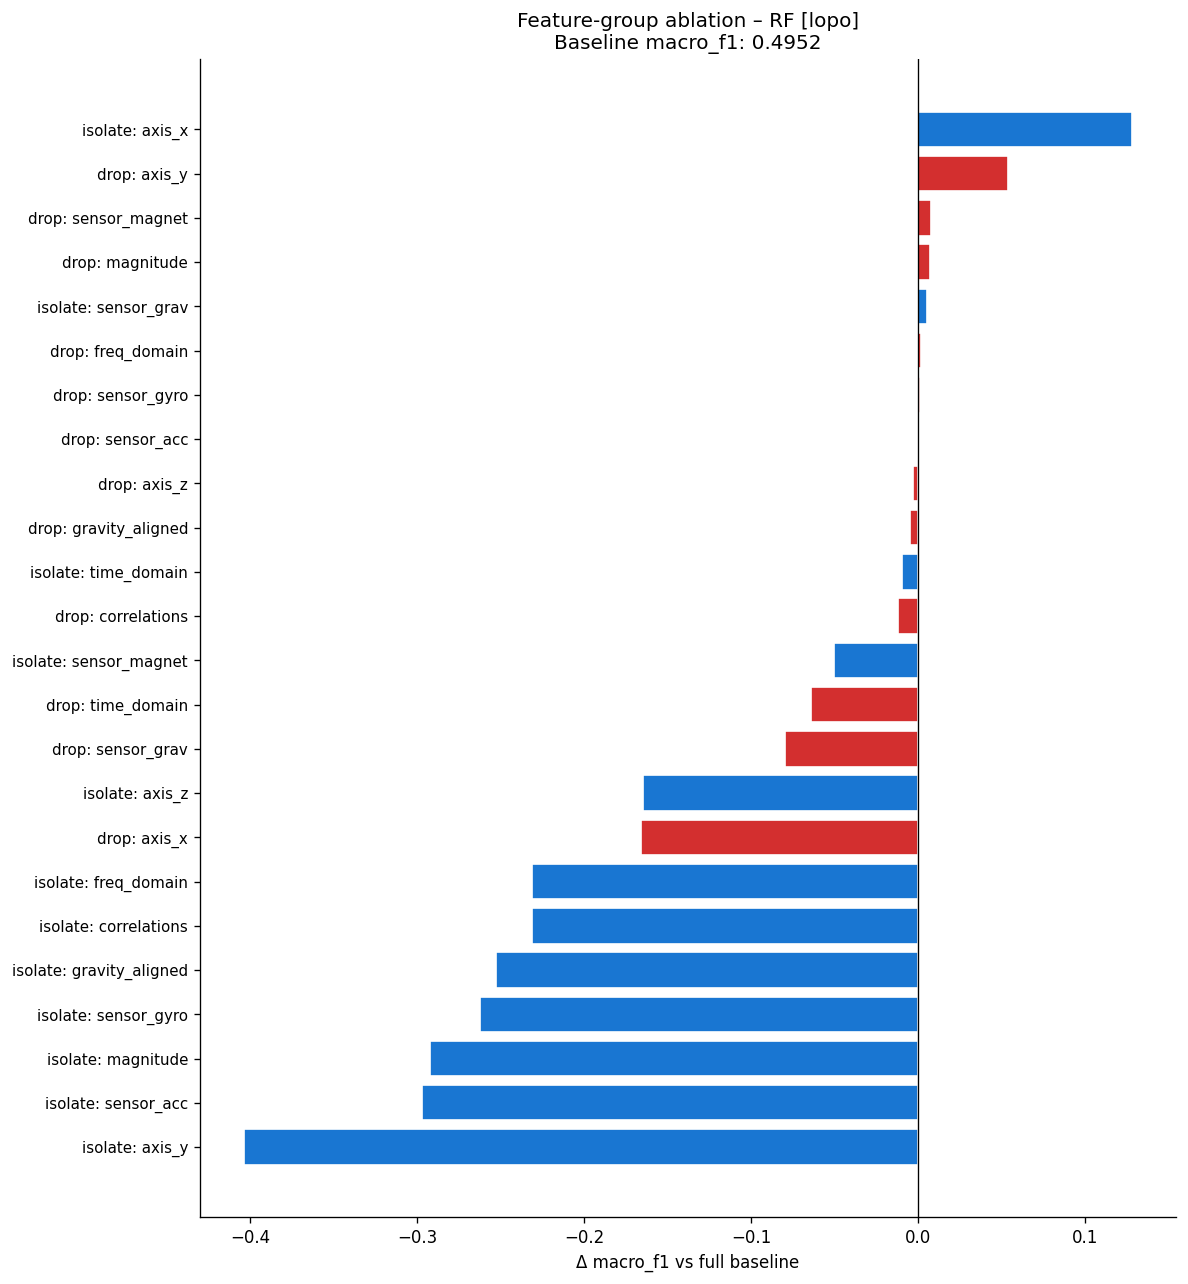

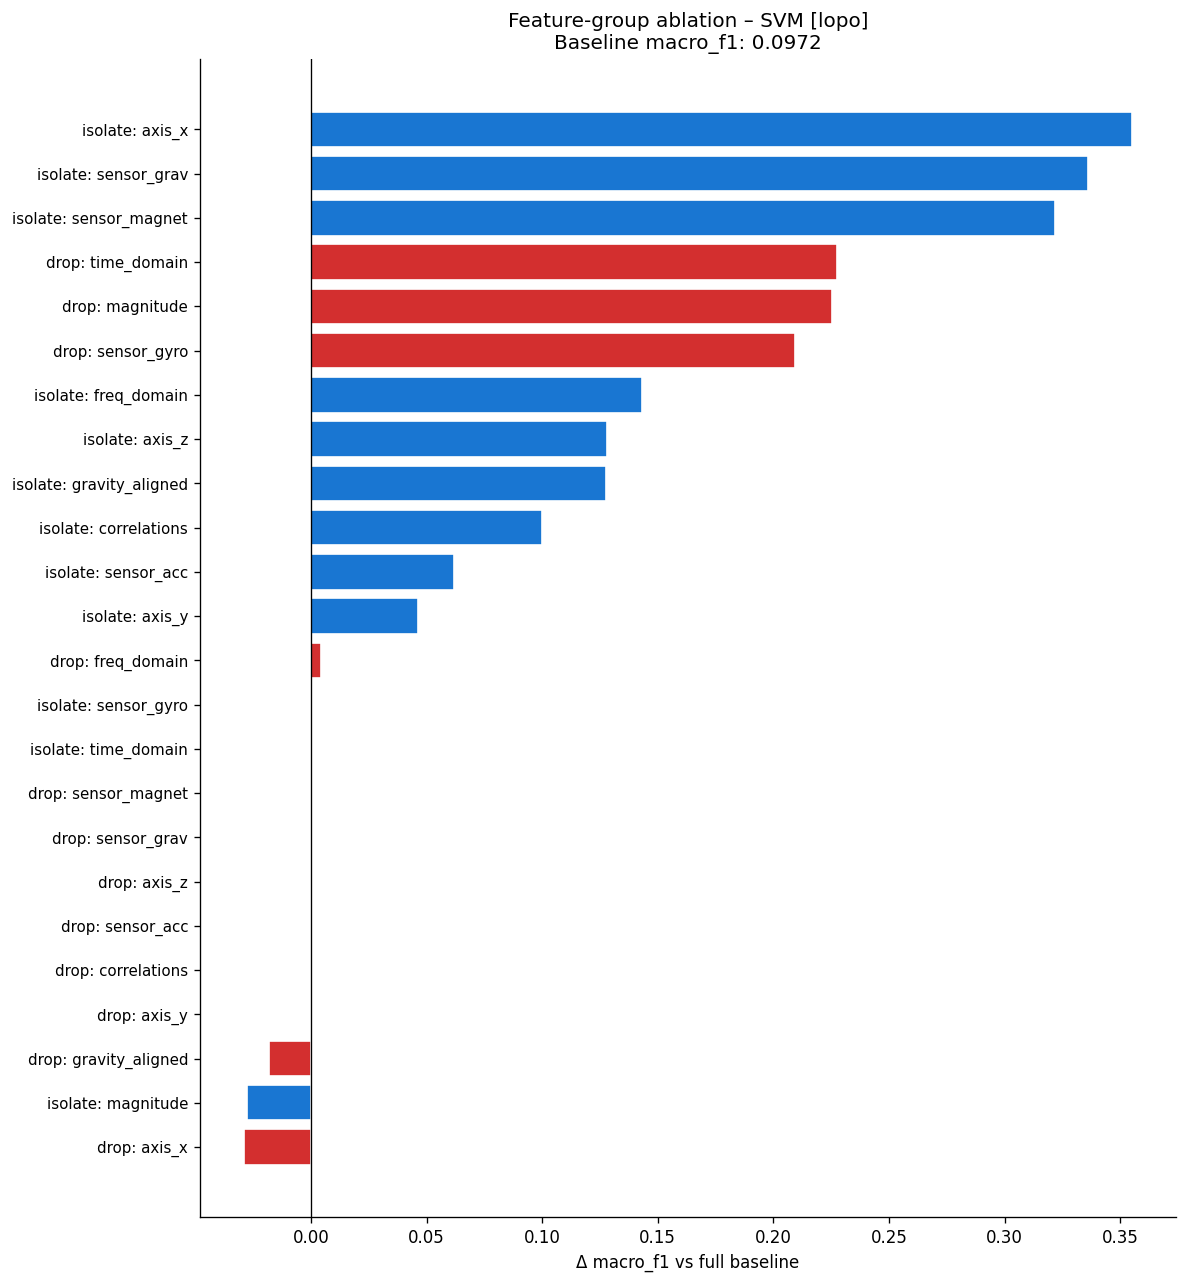

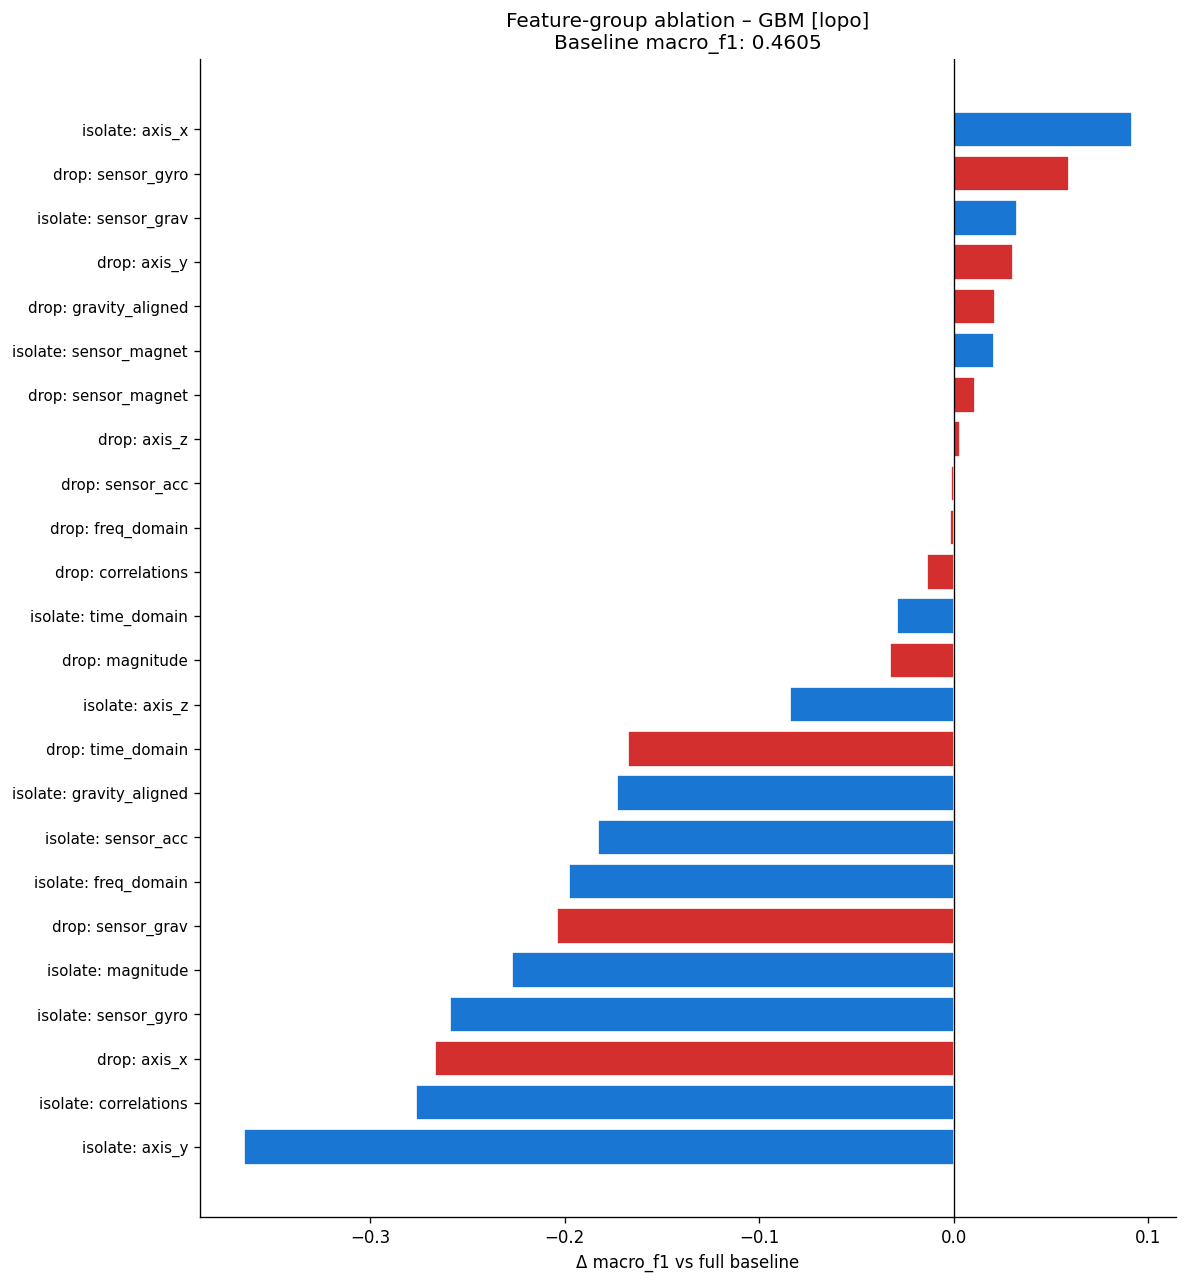

  Results saved → ./Results\evaluation_partial.json
  Results saved → ./Results\evaluation_20260613_025732.json

Results available for strategies: ['session_blocked', 'lopo']


In [7]:
# ── 5b. RUN LOPO ──────────────────────────────────────────────────────────────
import numpy as np
from Python.evaluation import run_full_evaluation

# Build raw sequences array (N, T, 10) expected by the DL models
_DL_CHANNELS = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "acc_vert", "acc_horiz", "gyro_vert", "gyro_horiz",
]
sequences = np.stack(
    [np.stack([w[ch] for ch in _DL_CHANNELS], axis=-1) for w in windowed_data]
)  # (N, T, 10)
print(f"Sequences shape: {sequences.shape}")

# Resume from partial save if lopo already completed
_lopo_done = False
if os.path.exists(PARTIAL):
    with open(PARTIAL) as f:
        _partial = json.load(f)
    if "lopo" in _partial:
        print("lopo already completed — loading from partial save.")
        results["lopo"] = _partial["lopo"]
        _lopo_done = True

if not _lopo_done:
    print("Running lopo evaluation...")
    lopo_res = run_full_evaluation(
        features               = features,
        labels                 = labels,
        feature_names          = feature_names,
        metadata               = metadata,
        sequences              = sequences,
        run_dl_models          = True,
        run_ablation_classical = True,
        run_ablation_dl        = False,
        classical_models       = ("rf", "svm", "gbm"),
        dl_model_types         = ("cnn", "lstm", "cnn_lstm", "tcn"),
        dl_epochs              = 50,
        dl_batch_size          = 32,
        plots_dir              = PLOTS_DIR,
        save_dir               = SAVE_DIR,
        verbose                = True,
        strategies             = ("lopo",),
    )
    results.update(lopo_res)

print(f"\nResults available for strategies: {list(results.keys())}")

In [8]:
# ── 6. BENCHMARK COMPARISON TABLE ────────────────────────────────────────────
import pandas as pd

rows = []
for strategy in ("session_blocked", "lopo"):
    strat = results[strategy]
    for mt, res in strat.get("classical", {}).items():
        rows.append({
            "Protocol": strategy, "Model": mt.upper(), "Type": "Classical",
            "Macro-F1":    round(res["mean_macro_f1"],     4),
            "Bal. Acc":    round(res["mean_balanced_acc"], 4),
            "Accuracy":    round(res["mean_accuracy"],     4),
        })
    for mt, res in strat.get("dl", {}).items():
        if res and "mean_macro_f1" in res:
            rows.append({
                "Protocol": strategy, "Model": mt.upper(), "Type": "DL",
                "Macro-F1":    round(res["mean_macro_f1"],     4),
                "Bal. Acc":    round(res["mean_balanced_acc"], 4),
                "Accuracy":    round(res["mean_accuracy"],     4),
            })

df_bench = pd.DataFrame(rows).set_index(["Protocol", "Model"])
print("\n=== Benchmark Results ===")
df_bench


=== Benchmark Results ===


Type  Macro-F1  Bal. Acc  Accuracy
Protocol        Model                                            
session_blocked RF        Classical    0.9753    0.9751    0.9751
                SVM       Classical    0.9728    0.9729    0.9708
                GBM       Classical    0.9733    0.9716    0.9736
                CNN              DL    0.9799    0.9805    0.9787
                LSTM             DL    0.9633    0.9690    0.9680
                CNN_LSTM         DL    0.9732    0.9781    0.9765
                TCN              DL    0.9826    0.9830    0.9823
lopo            RF        Classical    0.4952    0.6165    0.6999
                SVM       Classical    0.0972    0.2250    0.2788
                GBM       Classical    0.4605    0.5313    0.5727
                CNN              DL    0.4900    0.5817    0.6585
                LSTM             DL    0.3353    0.4426    0.4132
                CNN_LSTM         DL    0.3727    0.4942    0.4722
                TCN              DL    0.4774    0.5874    0.5858

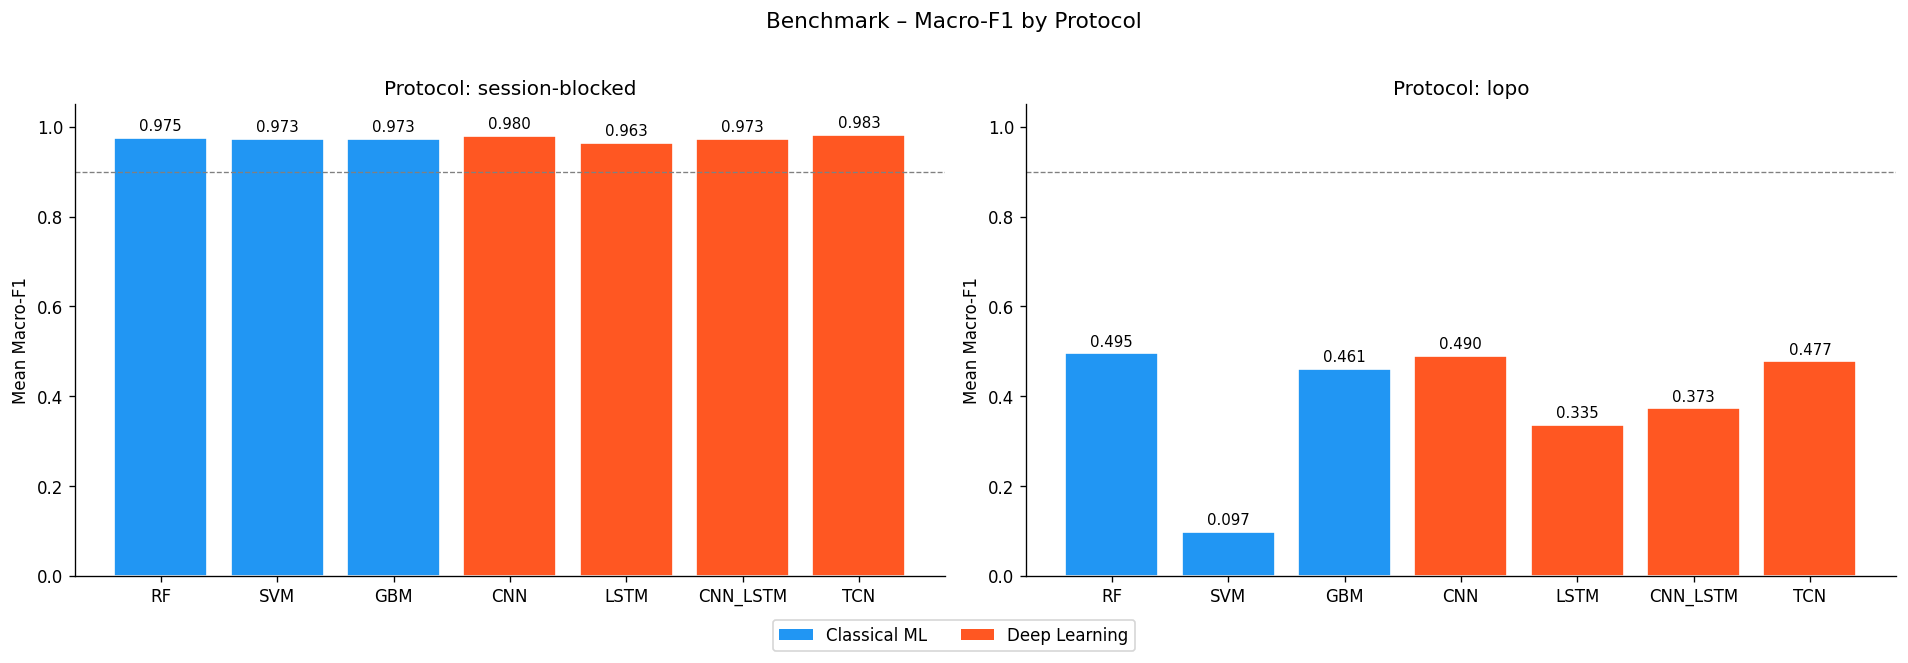

In [9]:
# ── 7. BENCHMARK BAR CHART ───────────────────────────────────────────────────
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

for ax, strategy in zip(axes, ("session_blocked", "lopo")):
    sub = df_bench.xs(strategy, level="Protocol").reset_index()
    palette = ["#2196F3" if t == "Classical" else "#FF5722" for t in sub["Type"]]
    bars = ax.bar(sub["Model"], sub["Macro-F1"], color=palette, edgecolor="white")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Mean Macro-F1")
    ax.set_title(f"Protocol: {strategy.replace('_', '-')}")
    ax.axhline(0.9, color="gray", linestyle="--", linewidth=0.8)
    for bar, val in zip(bars, sub["Macro-F1"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="Classical ML"),
    Patch(facecolor="#FF5722", label="Deep Learning"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.06))
plt.suptitle("Benchmark – Macro-F1 by Protocol", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("./Plots/benchmark_macro_f1.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ── 8. SESSION-BLOCKED vs LOPO GENERALISATION GAP ────────────────────────────
# A large drop from session_blocked → lopo indicates that features capture
# participant- or device-specific patterns rather than exercise dynamics.

gap_rows = []
for model in df_bench.index.get_level_values("Model").unique():
    try:
        sb  = df_bench.loc[("session_blocked", model), "Macro-F1"]
        lp  = df_bench.loc[("lopo",            model), "Macro-F1"]
        gap_rows.append({"Model": model, "Session-blocked": sb,
                         "LOPO": lp, "Gap (SB - LOPO)": round(sb - lp, 4)})
    except KeyError:
        pass

df_gap = pd.DataFrame(gap_rows).set_index("Model").sort_values("Gap (SB - LOPO)", ascending=False)
print("\n=== Generalisation Gap (Macro-F1) ===")
print("Positive gap → model relies on participant/device cues.")
df_gap


=== Generalisation Gap (Macro-F1) ===
Positive gap → model relies on participant/device cues.


,Session-blocked,LOPO,Gap (SB - LOPO)
Model,,,
SVM,0.9728,0.0972,0.8756
LSTM,0.9633,0.3353,0.6280
CNN_LSTM,0.9732,0.3727,0.6005
GBM,0.9733,0.4605,0.5128
TCN,0.9826,0.4774,0.5052
CNN,0.9799,0.4900,0.4899
RF,0.9753,0.4952,0.4801


In [11]:
# ── 9. ABLATION RESULTS TABLE ─────────────────────────────────────────────────
# Show the delta in Macro-F1 vs full-feature baseline for the RF model
# under both evaluation protocols.

def ablation_delta_table(results, strategy, metric="mean_macro_f1", model="rf"):
    abl = results[strategy].get("ablation_classical", {})
    if not abl:
        print(f"No ablation results for {strategy}.")
        return pd.DataFrame()
    baseline = abl.get("full", {}).get(model, {}).get(metric, float("nan"))
    rows = []
    for cond, res in abl.items():
        val = res.get(model, {}).get(metric, float("nan"))
        rows.append({
            "Condition": cond,
            metric:     round(val, 4),
            "delta":    round(val - baseline, 4) if cond != "full" else 0.0,
        })
    df = pd.DataFrame(rows).set_index("Condition")
    return df.sort_values("delta")

for strategy in ("session_blocked", "lopo"):
    print(f"\n=== Ablation – RF – {strategy} (Macro-F1 delta) ===")
    display(ablation_delta_table(results, strategy, metric="mean_macro_f1", model="rf"))


=== Ablation – RF – session_blocked (Macro-F1 delta) ===


,mean_macro_f1,delta
Condition,,
isolate_sensor_gyro,0.9464,-0.0289
isolate_gravity_aligned,0.9542,-0.0211
isolate_magnitude,0.9566,-0.0187
isolate_axis_y,0.9590,-0.0163
isolate_sensor_acc,0.9612,-0.0141
isolate_axis_x,0.9641,-0.0112
isolate_axis_z,0.9646,-0.0107
isolate_freq_domain,0.9655,-0.0098
isolate_correlations,0.9688,-0.0065



=== Ablation – RF – lopo (Macro-F1 delta) ===


,mean_macro_f1,delta
Condition,,
isolate_axis_y,0.0918,-0.4034
isolate_sensor_acc,0.1985,-0.2967
isolate_magnitude,0.2028,-0.2924
isolate_sensor_gyro,0.2330,-0.2622
isolate_gravity_aligned,0.2427,-0.2525
isolate_correlations,0.2641,-0.2311
isolate_freq_domain,0.2644,-0.2308
drop_axis_x,0.3296,-0.1656
isolate_axis_z,0.3305,-0.1647


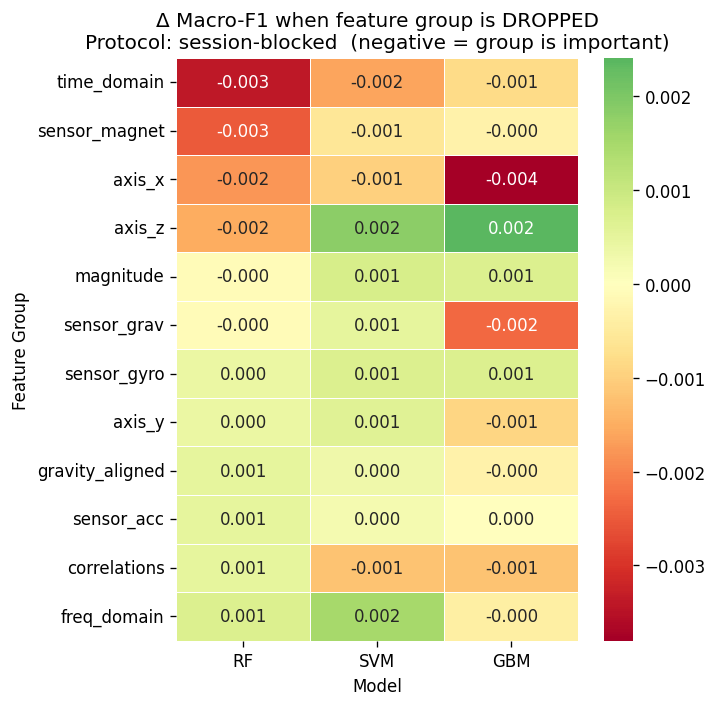

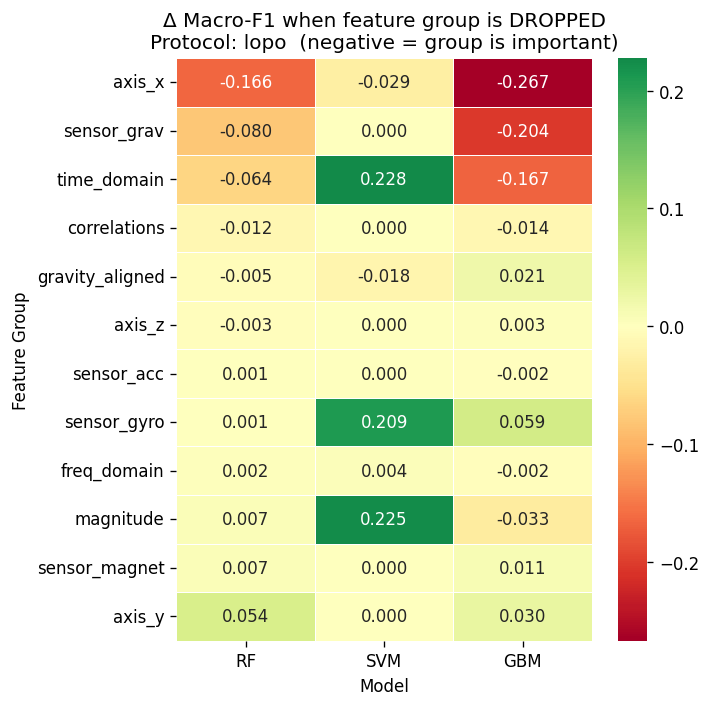

In [12]:
# ── 10. ABLATION HEAT-MAP (all classical models × all groups) ─────────────────
# Rows = feature groups (drop conditions only), columns = models.
# Cell value = Macro-F1 delta vs full baseline.
# Red = dropping that group hurts performance (group is important).

def ablation_heatmap(results, strategy, metric="mean_macro_f1", models=("rf", "svm", "gbm")):
    abl = results[strategy].get("ablation_classical", {})
    if not abl:
        print(f"No ablation data for {strategy}.")
        return
    baseline = {m: abl.get("full", {}).get(m, {}).get(metric, float("nan")) for m in models}
    drop_conds = [c for c in abl if c.startswith("drop_")]
    data = {}
    for cond in drop_conds:
        group = cond.replace("drop_", "")
        data[group] = {
            m.upper(): round(abl[cond].get(m, {}).get(metric, float("nan")) - baseline[m], 4)
            for m in models
        }
    df = pd.DataFrame(data).T.sort_values(list(data[list(data.keys())[0]].keys())[0])

    fig, ax = plt.subplots(figsize=(max(6, len(models) * 2), max(4, len(df) * 0.5)))
    sns.heatmap(
        df.astype(float), annot=True, fmt=".3f", cmap="RdYlGn",
        center=0, linewidths=0.5, ax=ax,
    )
    ax.set_title(f"Δ Macro-F1 when feature group is DROPPED\n"
                 f"Protocol: {strategy.replace('_', '-')}  "
                 f"(negative = group is important)")
    ax.set_xlabel("Model")
    ax.set_ylabel("Feature Group")
    plt.tight_layout()
    plt.savefig(f"./Plots/ablation_heatmap_{strategy}.png", dpi=150, bbox_inches="tight")
    plt.show()
    return df

for strategy in ("session_blocked", "lopo"):
    ablation_heatmap(results, strategy)


=== Ablation generalisation check – RF ===
'SB - LOPO' > 0: feature group is relatively more important within-session
than across participants, suggesting participant/device specificity.


Protocol,lopo,session_blocked,SB - LOPO
Group,,,
axis_x,-0.1656,-0.0018,0.1638
sensor_grav,-0.0798,-0.0001,0.0797
time_domain,-0.0639,-0.0034,0.0605
correlations,-0.0118,0.0005,0.0123
gravity_aligned,-0.0051,0.0005,0.0056
axis_z,-0.0031,-0.0015,0.0016
sensor_acc,0.0005,0.0005,0.0000
sensor_gyro,0.0014,0.0004,-0.0010
freq_domain,0.0018,0.0007,-0.0011


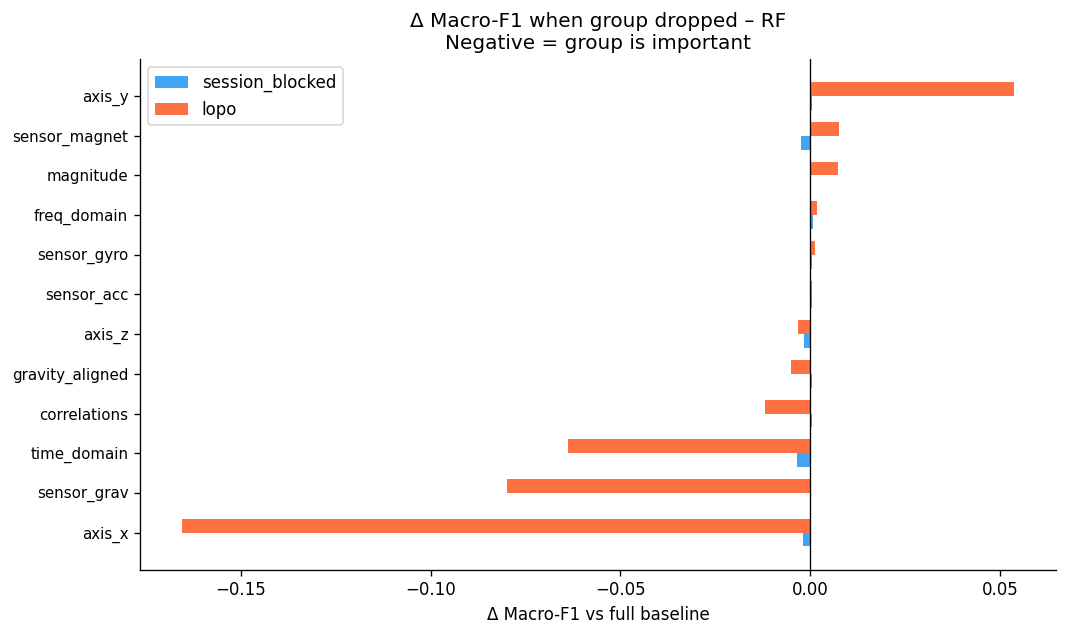

In [13]:
# ── 11. GENERALISATION CHECK FOR ABLATION GROUPS ─────────────────────────────
# Compare Δ Macro-F1 for each group under session_blocked vs lopo.
# Groups that help under session_blocked but not lopo may capture
# participant- or device-specific cues rather than exercise dynamics.

def ablation_generalisation(results, model="rf", metric="mean_macro_f1"):
    rows = []
    for strategy in ("session_blocked", "lopo"):
        abl = results[strategy].get("ablation_classical", {})
        if not abl:
            continue
        baseline = abl.get("full", {}).get(model, {}).get(metric, float("nan"))
        for cond, res in abl.items():
            if not cond.startswith("drop_"):
                continue
            group = cond.replace("drop_", "")
            val   = res.get(model, {}).get(metric, float("nan"))
            rows.append({"Group": group, "Protocol": strategy,
                         "delta": round(val - baseline, 4)})
    if not rows:
        return
    df = pd.DataFrame(rows).pivot(index="Group", columns="Protocol", values="delta")
    df["SB - LOPO"] = df.get("session_blocked", float("nan")) - df.get("lopo", float("nan"))
    df = df.sort_values("SB - LOPO", ascending=False)

    print(f"\n=== Ablation generalisation check – {model.upper()} ===")
    print("'SB - LOPO' > 0: feature group is relatively more important within-session")
    print("than across participants, suggesting participant/device specificity.")
    display(df)

    fig, ax = plt.subplots(figsize=(9, max(4, len(df) * 0.45)))
    x = range(len(df))
    ax.barh(x, df.get("session_blocked", [0]*len(df)), 0.35,
            label="session_blocked", color="#2196F3", alpha=0.85)
    ax.barh([i + 0.35 for i in x], df.get("lopo", [0]*len(df)), 0.35,
            label="lopo", color="#FF5722", alpha=0.85)
    ax.set_yticks([i + 0.175 for i in x])
    ax.set_yticklabels(df.index, fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Δ Macro-F1 vs full baseline")
    ax.set_title(f"Δ Macro-F1 when group dropped – {model.upper()}\n"
                 "Negative = group is important")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"./Plots/ablation_generalisation_{model}.png", dpi=150, bbox_inches="tight")
    plt.show()

ablation_generalisation(results, model="rf")